In [40]:
import pandas as pd
import numpy as np
import os

In [41]:
folderpath = os.getcwd()
filepath = os.path.join(folderpath, "data\sample.csv")

df = pd.read_csv(filepath, sep=",")

In [42]:
df['score'] = pd.to_numeric(df['score'].astype(str).str.replace(',', '.'), errors = 'coerce')
df['epss'] = pd.to_numeric(df['epss'].astype(str).str.replace(',', '.'), errors = 'coerce')

df['cvss'] = df['cvss'].fillna(0)

df = df.drop(columns = ['vpr_score', 'siem'])

print(df.dtypes)
print(df.isnull().sum())

asset_ip              object
score                float64
cvss                 float64
epss                 float64
asset_criticality      int64
asset_exposure         int64
vuln_state            object
first_seen            object
last_seen             object
severity_label        object
cisa                    bool
is_cve_trend            bool
reference_date        object
dtype: object
asset_ip             7497
score                   0
cvss                    0
epss                    0
asset_criticality       0
asset_exposure          0
vuln_state              0
first_seen              0
last_seen               0
severity_label        619
cisa                    0
is_cve_trend            0
reference_date          0
dtype: int64


In [43]:
df['first_seen'] = pd.to_datetime(df['first_seen'])
df['last_seen'] = pd.to_datetime(df['last_seen'])

df['months_open'] = (
    (df['last_seen'] - df['first_seen'])
    / pd.Timedelta(days=30)
).round(0)

hosts = df.groupby('asset_ip').agg(
    vuln_count        = ('score', 'count'),
    score_mean      = ('score', 'mean'),
    score_max        = ('score', 'max'),
    cvss_mean       = ('cvss', 'mean'),
    epss_mean       = ('epss', 'mean'),
    exposure        = ('asset_exposure', 'max'),
    cisa_count         = ('cisa', 'sum'),
    cve_trend_count    = ('is_cve_trend', 'sum'),
    months_open_max = ('months_open', 'max'),
).reset_index()

print(hosts.shape)
print(hosts.head())


(254, 10)
      asset_ip  vuln_count  score_mean  score_max  cvss_mean  epss_mean  \
0    192.0.2.1           7   18.914286       22.6   7.957143   0.000000   
1   192.0.2.10          13   16.923077       22.6   6.884615   0.030000   
2  192.0.2.100          11   19.054545       23.0   8.027273   0.000909   
3  192.0.2.101          27   21.422222       30.3   8.137037   0.097037   
4  192.0.2.102          26   18.111538       30.3   7.369231   0.036538   

   exposure  cisa_count  cve_trend_count  months_open_max  
0         3           0                0              4.0  
1         3           0                1              5.0  
2         3           0                0              5.0  
3         3           9                0              5.0  
4         3           1                0              5.0  


In [44]:
from sklearn.preprocessing import MinMaxScaler

features = ['vuln_count', 'score_mean', 'score_max', 'cvss_mean', 
            'epss_mean', 'exposure', 'cisa_count', 'cve_trend_count', 
            'months_open_max']
            
X = hosts[features]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Antes:", X['score_mean'].min(), "a", X['score_mean'].max())
print("Depois:", X_scaled[:, 1].min(), "a", X_scaled[:, 1].max()) #1=coluna score_mean (X  = array [não mais df])

Antes: 3.0 a 30.93820224719101
Depois: 0.0 a 1.0


In [51]:
from sklearn.cluster import KMeans
import plotly.graph_objects as go

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(k_range),
    y=inertias,
    mode='lines+markers',
    marker=dict(size=8, color='#2563eb'),
    line=dict(color='#2563eb', width=2),
    hovertemplate='K = %{x}<br>Inertia = %{y:.2f}<extra></extra>'
))

fig.update_layout(
    title=dict(text='Elbow Method — Optimal Number of Clusters', font=dict(size=18)),
    xaxis=dict(title='Number of Clusters', tickmode='linear', dtick=1, gridcolor='#e5e7eb'),
    yaxis=dict(title='Inertia', gridcolor='#e5e7eb'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x',
    width=800,
    height=450
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [46]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
hosts['cluster'] = km_final.fit_predict(X_scaled)

print(hosts['cluster'].value_counts().sort_index())

cluster
0     81
1    121
2     46
3      6
Name: count, dtype: int64


In [47]:
perfil = hosts.groupby('cluster')[features].mean().round(2)
print(perfil.T)

cluster              0      1      2      3
vuln_count        4.53  12.79   9.52  81.17
score_mean        8.74  16.93  17.42  22.41
score_max        14.62  24.91  21.93  33.52
cvss_mean         2.86   6.64   6.95   8.01
epss_mean         0.01   0.07   0.02   0.11
exposure          3.00   3.00   3.00   3.00
cisa_count        0.00   1.26   1.15  18.67
cve_trend_count   0.26   0.57   0.57   5.83
months_open_max   4.80   4.89   0.96   4.83


In [48]:
nomes = {0: 'Critical', 1: 'High', 2: 'Moderate', 3: 'Low'}

hosts['risk_profile'] = hosts['cluster'].map(nomes)

print(hosts[['asset_ip', 'cluster', 'risk_profile']].head(10))

hosts.to_csv('hosts_clusterizados.csv', index=False)

      asset_ip  cluster risk_profile
0    192.0.2.1        1         High
1   192.0.2.10        1         High
2  192.0.2.100        1         High
3  192.0.2.101        1         High
4  192.0.2.102        1         High
5  192.0.2.103        1         High
6  192.0.2.104        0     Critical
7  192.0.2.105        1         High
8  192.0.2.106        1         High
9  192.0.2.107        1         High


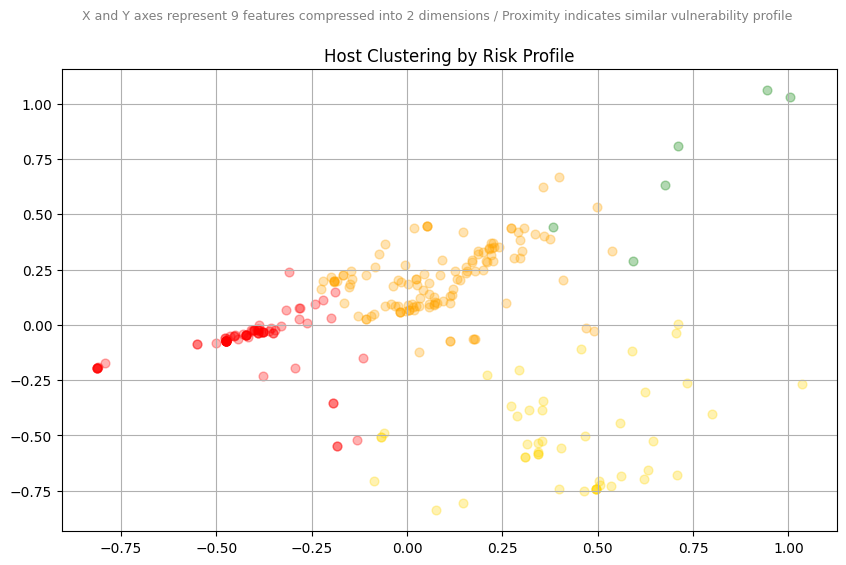

In [49]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA reduz as 9 features pra 2 dimensões for 2D plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Colors by profile
cores = {0: 'red', 1: 'orange', 2: 'gold', 3: 'green'}
labels = {0: 'Critical', 1: 'High', 2: 'Moderate', 3: 'Low'}

plt.figure(figsize=(10, 6))
for cluster_id, cor in cores.items():
    mask = hosts['cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=cor, label=labels[cluster_id], alpha=0.3, s=40)

plt.title('Host Clustering by Risk Profile')
plt.suptitle('X and Y axes represent 9 features compressed into 2 dimensions / Proximity indicates similar vulnerability profile', 
             fontsize=9, color='gray', y=0.98)
plt.grid(True)
plt.show()